In [2]:
import pandas as pd
import numpy as np

# Load the CSV file
df = pd.read_csv('gym_raw.csv')

def generate_feedback_realistic(row, flip_prob=0.10):
    churn = row['Churn']
    age = row['Age']
    partner = row['Partner']
    contract = row['Contract_period']
    freq_current = row['Avg_class_frequency_current_month']
    charges = row['Avg_additional_charges_total']
    lifetime = row['Lifetime_in_the _gym']
    location = row['Near_Location']

    # 1. Determine the effective sentiment status (introducing noise)
    effective_churn = churn
    if np.random.rand() < flip_prob:
        # Flip the sentiment for 'flip_prob' (10%) of customers
        effective_churn = 'Left' if churn == 'Stayed' else 'Stayed'

    # 2. Generate feedback based on the effective_churn status
    if effective_churn == 'Left':
        # Negative Reviews
        reasons = []
        if partner == 'No':
            reasons.append("didn't offer a corporate rate")
        if contract == 1:
            reasons.append("the short-term contract wasn't a good fit")
        if freq_current < 1:
            reasons.append("I wasn't using the classes enough")
        if charges > 150:
            reasons.append("the additional charges were too high")
        if lifetime <= 2:
            reasons.append("I never really settled in")

        if not reasons or np.random.rand() < 0.2: # 20% chance of a generic negative
            feedback = f"Disappointing experience. I'm {age} and felt this gym wasn't worth the money. I found a better option."
        else:
            feedback = f"I decided to leave. Frankly, {', and '.join(reasons)}. It was an overall negative experience."

    else:
        # Positive Reviews
        aspects = []
        if partner == 'Yes':
            aspects.append("The corporate discount is fantastic.")
        if contract >= 6:
            aspects.append("The value of the 6+ month contract is great.")
        if freq_current > 2:
            aspects.append("I love how often I can attend classes, I'm practically here every day!")
        if charges > 100 and lifetime > 3:
            aspects.append("I enjoy the extra services like the spa and bar—they make the experience better.")
        if location == 'Near':
            aspects.append("The proximity to my home makes it very convenient.")

        if not aspects or np.random.rand() < 0.2: # 20% chance of a generic positive
            feedback = f"Great gym! As a {age}-year-old, I appreciate the consistent service and clean facilities. I'll definitely be renewing."
        else:
            feedback = f"This gym is excellent. {' '.join(aspects)} I highly recommend it to anyone in the area."

    return feedback

# Apply the modified function to create the new column
df['Synthetic_Feedback'] = df.apply(lambda row: generate_feedback_realistic(row, flip_prob=0.10), axis=1)

# Save the final DataFrame with the new column to a CSV file (not included in your code request but is good practice)
df.to_csv('gym_data_with_feedback.csv', index=False)

### Data Preprocessing

In [3]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download NLTK data if not already present
for resource in ['wordnet', 'stopwords', 'omw-1.4']:
    try:
        nltk.data.find(f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

# Load the DataFrame
df = pd.read_csv('gym_data_with_feedback.csv')

# Initialize Lemmatizer and Stop Words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove punctuation except numbers and "+"
    text = re.sub(f"[{re.escape(string.punctuation.replace('+',''))}]", "", text)
    
    # 3. Tokenize (keep words and numbers)
    words = re.findall(r'\b[a-z0-9]+\b', text)
    
    # 4. Remove stopwords and lemmatize
    processed_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(processed_words)

# Apply preprocessing
df['Processed_Feedback'] = df['Synthetic_Feedback'].apply(preprocess_text)

# Save CSV in the desired format
df.to_csv('gym_data_processed_for_nlp.csv', index=False, quoting=1)  # quoting=1 ensures quotes around text

# Display a preview
print(df[['Synthetic_Feedback', 'Processed_Feedback']].head().to_markdown(index=False))


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


| Synthetic_Feedback                                                                                                                                                                                                                                   | Processed_Feedback                                                                                                                                             |
|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------|
| This gym is excellent. The corporate discount is fantastic. The value of the 6+ month contract is great. The proximity to my home makes it very convenient. I highly recommend it 

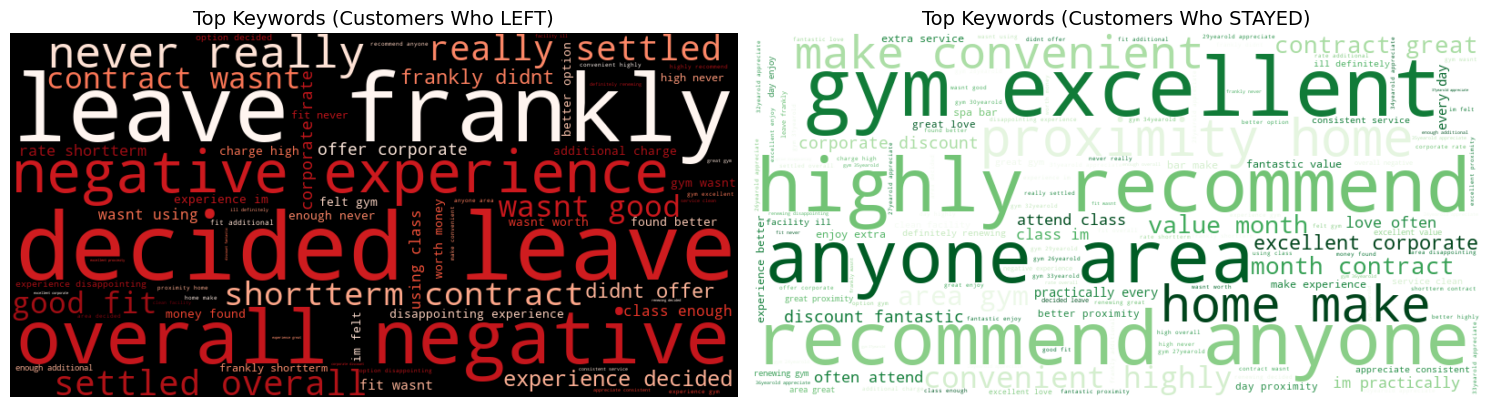

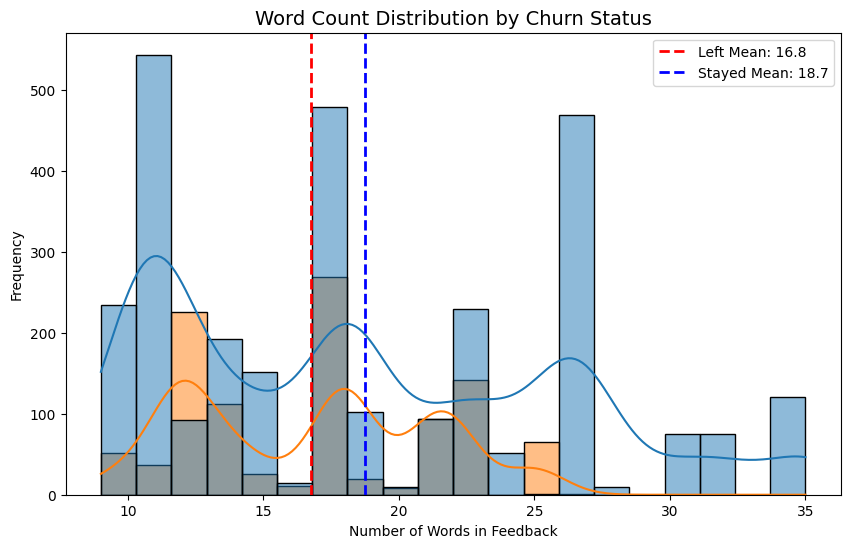


--- Summary: Word Count by Churn Status ---
Mean Word Count (LEFT): 16.76
Mean Word Count (STAYED): 18.74

Top 15 Most Frequent Words (Customers Who LEFT):
| Word       | Count   |
|:-----------|:--------|
| wasnt      | 1262    |
| experience | 970     |
| decided    | 751     |
| leave      | 751     |
| frankly    | 751     |
| overall    | 751     |
| negative   | 751     |
| never      | 691     |
| really     | 691     |
| settled    | 691     |
| contract   | 674     |
| shortterm  | 664     |
| good       | 664     |
| fit        | 664     |
| corporate  | 504     |

Top 15 Most Frequent Words (Customers Who STAYED):
| Word       | Count   |
|:-----------|:--------|
| gym        | 2707    |
| make       | 2595    |
| excellent  | 2107    |
| highly     | 2107    |
| recommend  | 2107    |
| anyone     | 2107    |
| area       | 2107    |
| proximity  | 1846    |
| home       | 1846    |
| convenient | 1846    |
| great      | 1735    |
| contract   | 1331    |
| corporate  | 1

In [28]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np

# Load the data (using the file with the Processed_Feedback column)
df = pd.read_csv('gym_data_processed_for_nlp.csv')

# --- 1. Vocabulary Analysis: Word Frequencies ---

# Separate feedback by Churn status
left_feedback = ' '.join(df[df['Churn'] == 'Left']['Processed_Feedback'].astype(str))
stayed_feedback = ' '.join(df[df['Churn'] == 'Stayed']['Processed_Feedback'].astype(str))

# Calculate word frequencies for each group
left_words = left_feedback.split()
stayed_words = stayed_feedback.split()

# Get top 15 words for a bar plot
left_top_15 = Counter(left_words).most_common(15)
stayed_top_15 = Counter(stayed_words).most_common(15)

# Generate Word Clouds 
wordcloud_left = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(left_feedback)
wordcloud_stayed = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(stayed_feedback)

# Plotting Word Clouds
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_left, interpolation='bilinear')
plt.title('Top Keywords (Customers Who LEFT)', fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_stayed, interpolation='bilinear')
plt.title('Top Keywords (Customers Who STAYED)', fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

# --- 2. Text Structure Analysis: Document Length Distribution ---

# Calculate the length of the processed feedback (number of words)
df['Word_Count'] = df['Processed_Feedback'].apply(lambda x: len(str(x).split()))

# Calculate the mean and median word counts
left_mean_count = df[df['Churn'] == 'Left']['Word_Count'].mean()
stayed_mean_count = df[df['Churn'] == 'Stayed']['Word_Count'].mean()

# Plotting Word Count Distribution 
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Word_Count', hue='Churn', kde=True, bins=20)
plt.title('Word Count Distribution by Churn Status', fontsize=14)
plt.axvline(left_mean_count, color='red', linestyle='dashed', linewidth=2, label=f'Left Mean: {left_mean_count:.1f}')
plt.axvline(stayed_mean_count, color='blue', linestyle='dashed', linewidth=2, label=f'Stayed Mean: {stayed_mean_count:.1f}')
plt.xlabel('Number of Words in Feedback')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Print summary statistics
print("\n--- Summary: Word Count by Churn Status ---")
print(f"Mean Word Count (LEFT): {left_mean_count:.2f}")
print(f"Mean Word Count (STAYED): {stayed_mean_count:.2f}")
print("\nTop 15 Most Frequent Words (Customers Who LEFT):")
print(pd.DataFrame(left_top_15, columns=['Word', 'Count']).to_markdown(index=False, numalign='left', stralign='left'))
print("\nTop 15 Most Frequent Words (Customers Who STAYED):")
print(pd.DataFrame(stayed_top_15, columns=['Word', 'Count']).to_markdown(index=False, numalign='left', stralign='left'))

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the processed data
df = pd.read_csv('gym_data_processed_for_nlp.csv')

# --- 1. Define Features (X) and Target (y) ---
X = df['Processed_Feedback']
# Convert 'Churn' (Stayed/Left) to numerical labels (0/1)
# We'll map 'Left' to 1 (Positive class for the classification report) and 'Stayed' to 0.
y = df['Churn'].apply(lambda x: 1 if x == 'Left' else 0)

# --- 2. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Vectorization (TF-IDF) ---
tfidf = TfidfVectorizer(max_features=5000) # Use the top 5000 features
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# --- 4. Model Training (Logistic Regression) ---
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train_tfidf, y_train)

# --- 5. Prediction and Evaluation ---
y_pred = model.predict(X_test_tfidf)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)'], output_dict=True)

print(f"--- Sentiment Analysis Model Performance ---")
print(f"Accuracy: {accuracy:.4f}\n")
print(pd.DataFrame(report).transpose().to_markdown(numalign="left", stralign="left"))

--- Sentiment Analysis Model Performance ---
Accuracy: 0.9500

|              | precision   | recall   | f1-score   | support   |
|:-------------|:------------|:---------|:-----------|:----------|
| Stayed (0)   | 0.972414    | 0.959184 | 0.965753   | 588       |
| Left (1)     | 0.890909    | 0.924528 | 0.907407   | 212       |
| accuracy     | 0.95        | 0.95     | 0.95       | 0.95      |
| macro avg    | 0.931661    | 0.941856 | 0.93658    | 800       |
| weighted avg | 0.950815    | 0.95     | 0.950292   | 800       |


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# --- Load processed dataset ---
df = pd.read_csv('gym_data_processed_for_nlp.csv')
X = df['Processed_Feedback']
y = df['Churn'].apply(lambda x: 1 if x == 'Left' else 0)

# --- Split into train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Define models to compare ---
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

# --- Evaluate each model ---
results = []

for name, model in models.items():
    
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ('clf', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)']))

# --- Display Comparison Table ---
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))



--- Logistic Regression ---
              precision    recall  f1-score   support

  Stayed (0)       0.97      0.96      0.97       588
    Left (1)       0.89      0.92      0.91       212

    accuracy                           0.95       800
   macro avg       0.93      0.94      0.94       800
weighted avg       0.95      0.95      0.95       800


--- Naive Bayes ---
              precision    recall  f1-score   support

  Stayed (0)       0.98      0.93      0.95       588
    Left (1)       0.83      0.95      0.88       212

    accuracy                           0.93       800
   macro avg       0.90      0.94      0.92       800
weighted avg       0.94      0.93      0.94       800


--- Linear SVM ---
              precision    recall  f1-score   support

  Stayed (0)       0.97      0.97      0.97       588
    Left (1)       0.91      0.91      0.91       212

    accuracy                           0.95       800
   macro avg       0.94      0.94      0.94       800
weig

In [15]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Assume X_train, y_train are already defined from your 3rd cell

# Create pipeline with TF-IDF + Logistic Regression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', LogisticRegression(random_state=42, solver='liblinear'))
])

# Fit model
pipeline.fit(X_train, y_train)

# Save pipeline
joblib.dump(pipeline, 'sentiment_analysis_model.pkl')
print("✅  model saved as 'sentiment_analysis_model.pkl'")


✅  model saved as 'sentiment_analysis_model.pkl'


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from sklearn.metrics import classification_report

# --- Parameters ---
max_words = 10000     # Vocabulary size
max_len = 100         # Max sequence length
embedding_dim = 100
batch_size = 32
epochs = 5

# --- Tokenize text ---
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# --- Build LSTM / BiLSTM Model ---
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# --- Train Model ---
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# --- Evaluate Model ---
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n=== BiLSTM Model Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)']))


c:\Users\Administrator\Gym\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 181ms/step - accuracy: 0.8663 - loss: 0.3356 - val_accuracy: 0.8562 - val_loss: 0.3201
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - accuracy: 0.9028 - loss: 0.2586 - val_accuracy: 0.8625 - val_loss: 0.3058
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - accuracy: 0.9094 - loss: 0.2458 - val_accuracy: 0.8687 - val_loss: 0.2970
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.9142 - loss: 0.2288 - val_accuracy: 0.8781 - val_loss: 0.2753
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 165ms/step - accuracy: 0.9215 - loss: 0.2153 - val_accuracy: 0.8781 - val_loss: 0.3235
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step

=== BiLSTM Model Classification Report ===
              precision    recall  f1-score   support

  Stayed (0)       0.97      0.95      0.96       588
    Left (1)       0.88      0.92      0.90       212

    accuracy                           0.94       800
   macro avg       0.92      0.94      0.93       800
weig

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from sklearn.metrics import classification_report

# --- Parameters ---
max_words = 10000  # Vocabulary size
max_len = 100      # Maximum sequence length
embedding_dim = 100
batch_size = 32
epochs = 5

# --- Tokenize text ---
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# --- Build LSTM Model ---
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# --- Train model ---
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# --- Evaluate model ---
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n=== LSTM Model Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)']))


c:\Users\Administrator\Gym\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.7306 - loss: 0.5942 - val_accuracy: 0.7406 - val_loss: 0.5724
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7340 - loss: 0.5827 - val_accuracy: 0.7406 - val_loss: 0.5724
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.7340 - loss: 0.5847 - val_accuracy: 0.7406 - val_loss: 0.5812
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.7340 - loss: 0.5841 - val_accuracy: 0.7406 - val_loss: 0.5724
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.7340 - loss: 0.5807 - val_accuracy: 0.7406 - val_loss: 0.5736
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

=== LSTM Model Classification Report ===
              precision    recall  f1-score   support

  Stayed (0)       0.73      1.00      0.85       588
    Left (1)       0.00      0.00      0.00       212

    accuracy                           0.73       800
   macro avg       0.37      0.50      0.42       800
weighted avg

c:\Users\Administrator\Gym\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\Gym\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\Gym\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import re

# Hardcoded common English stop words (reusing the list)
COMMON_STOP_WORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've",
    "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his',
    'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself',
    'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom',
    'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were',
    'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did',
    'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up',
    'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then',
    'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both',
    'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will',
    'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're',
    've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't",
    'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't",
    'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn',
    "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't",
    'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

# --- Preprocessing Function ---
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    words = text.split()
    processed_words = [
        word for word in words
        if word not in COMMON_STOP_WORDS
    ]
    return " ".join(processed_words)

# Load the data
df = pd.read_csv('gym_data_with_feedback.csv')
df['Processed_Feedback'] = df['Synthetic_Feedback'].apply(preprocess_text)

# --- Re-run TF-IDF and LDA to get Dominant_Topic_ID ---
tfidf_vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_full_tfidf = tfidf_vectorizer.fit_transform(df['Processed_Feedback'])

NUM_TOPICS = 4
lda = LatentDirichletAllocation(n_components=NUM_TOPICS, random_state=42, learning_method='online')
lda.fit(X_full_tfidf)

topic_probabilities = lda.transform(X_full_tfidf)
df['Dominant_Topic_ID'] = np.argmax(topic_probabilities, axis=1) + 1

# --- Define Topic Mapping ---
# Using the topic names derived from the LDA output
topic_mapping = {
    1: 'Ambassadors (Positive)',
    2: 'High Usage / Engagement (Positive)',
    3: 'Value & Quality (High Churn Risk)',
    4: 'Hard Churn Signal (Medium Churn Risk)'
}
df['Dominant_Topic_Name'] = df['Dominant_Topic_ID'].map(topic_mapping)

# --- Define the Business Recommendation Function (The final deployed logic) ---
def generate_recommendation(row):
    topic = row['Dominant_Topic_Name']
    churn_status = row['Churn']

    if topic == 'Ambassadors (Positive)':
        return "Marketing: Send 'Referral Bonus' offer and request a public testimonial."

    elif topic == 'High Usage / Engagement (Positive)':
        return "Customer Success: Send a 'Loyalty Appreciation' gift (e.g., free merchandise) to reinforce commitment."

    elif topic == 'Value & Quality (High Churn Risk)':
        if churn_status == 'Left':
             return "Retention Team: Offer a 3-month 'Freeze' option or a 20% discount on the next contract to overcome the cost/value barrier."
        else:
             return "Customer Success: Flag as a flight risk. Proactively send survey for detailed feedback on specific service quality."

    elif topic == 'Hard Churn Signal (Medium Churn Risk)':
        if churn_status == 'Left':
             return "High-Priority Sales: Immediately call to conduct an exit interview. Offer a special 'Win-back' package."
        else:
             return "Immediate Customer Success: A positive customer is using hard churn keywords. Investigate recent incidents or bad interaction immediately."

    return "No Specific Action Required."

# Apply the function to generate the final business column
df['Business_Recommendation'] = df.apply(generate_recommendation, axis=1)

# Display the final, actionable output
print("\n--- Final Diagnostic Output with Business Recommendation ---")
print("This column is the final output of the NLP layer, ready for a deployment dashboard.")
print(df[['customer _ID', 'Churn', 'Synthetic_Feedback', 'Dominant_Topic_Name', 'Business_Recommendation']].sample(10, random_state=42).to_markdown(index=False, numalign="left", stralign="left"))

# Save the final, enhanced DataFrame for deployment reference
df.to_csv('gym_data_final_diagnostic.csv', index=False)


--- Final Diagnostic Output with Business Recommendation ---
This column is the final output of the NLP layer, ready for a deployment dashboard.
| customer _ID   | Churn   | Synthetic_Feedback                                                                                                                                                                                                                                                                        | Dominant_Topic_Name                   | Business_Recommendation                                                                                                                    |
|:---------------|:--------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------------|:-------

In [13]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
import re

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    words = text.split()
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Rejoin into one string
    text = ' '.join(words)
    return text

# Apply cleaning
df['Clean_Feedback'] = df['Customer_Feedback'].apply(clean_text)
df[['Customer_Feedback', 'Clean_Feedback']].head(10)


,Customer_Feedback,Clean_Feedback
0,Far from my home and not enough new equipment.,far home enough new equipment
1,Sometimes busy but overall an amazing experience.,sometimes busy overall amazing experience
2,"Too expensive for the value I get, I might can...",expensive value get might cancel soon
3,The gym is too crowded and the machines are of...,gym crowded machines often broken
4,"Good service, convenient location, and flexibl...",good service convenient location flexible memb...
5,The gym is too crowded and the machines are of...,gym crowded machines often broken
6,"Good service, convenient location, and flexibl...",good service convenient location flexible memb...
7,"Too expensive for the value I get, I might can...",expensive value get might cancel soon
8,Schedules are confusing and it’s always packed.,schedules confusing always packed
9,"Great environment and clean equipment, really ...",great environment clean equipment really enjoy...


In [9]:
df['word_count'] = df['Clean_Feedback'].apply(lambda x: len(x.split()))
df[['Churn', 'word_count']].groupby('Churn').mean()


,word_count
Churn,
0,9.696155
1,9.803959


In [6]:
# Convert churn to binary
df['Churn'] = df['Churn'].map({'Stayed': 0, 'Left': 1})


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numerical vectors
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
feedback_tfidf = tfidf.fit_transform(df['Customer_Feedback']).toarray()

# Create a DataFrame for the TF-IDF features
tfidf_df = pd.DataFrame(feedback_tfidf, columns=tfidf.get_feature_names_out())

# Combine with your numeric features (drop old text column)
df_final = pd.concat([df.drop(columns=['Customer_Feedback']), tfidf_df], axis=1)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split data
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ValueError: could not convert string to float: 'GYM_3995'